# Week 2 — Rx panel data and projection: a 10-minute tour
## How a vendor turns a sample of pharmacies into "national TRx" — and where it goes wrong

**Applied Data Science and AI in Pharma Commercial · Columbia DSI · Fall 2026 · Monday, September 21**

Week 1's core asymmetry: the manufacturer has no first-party data on prescriptions. What it buys is a **projected** view built from a **panel** of pharmacies that agree to share their dispensing data. Tonight's question is simple: *how much should you trust the number on the weekly brand report?*

The data is **synthetic** (fictional GLUCOREN, fictional pharmacies in six fictional ZIP3 areas). Three student files:

| file | grain | what it represents |
|---|---|---|
| `glucoren_panel_pharmacies.csv` | one row per **panel** pharmacy | the vendor's sample: ZIP3, type (Retail / Specialty / Mail), ownership, typical weekly volume |
| `glucoren_panel_weekly_trx.csv` | panel pharmacy × week | total TRx, GLUCOREN TRx / NRx, CARDIVEX TRx for 12 weeks |
| `glucoren_pharmacy_universe.csv` | ZIP3 × pharmacy type | what the vendor knows about the *whole* market: number of pharmacies and total weekly volume per stratum (from wholesaler / census data) |

The instructor holds the full universe (`_INSTRUCTOR_panel_universe_*.csv`) so we can grade the projection at the end.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
NAVY, CORAL, TEAL, GREY = "#1E2761", "#FF6B6B", "#2A9D8F", "#999999"
DATA = Path("data") if Path("data").exists() else Path(".")          # CSVs live in data/
INSTR = Path("instructor material") if Path("instructor material").exists() else DATA
panel = pd.read_csv(DATA / "glucoren_panel_pharmacies.csv", dtype={"zip3": str})
weekly = pd.read_csv(DATA / "glucoren_panel_weekly_trx.csv", parse_dates=["week_ending"])
universe = pd.read_csv(DATA / "glucoren_pharmacy_universe.csv", dtype={"zip3": str})
print(f"panel pharmacies {len(panel)} · weeks {weekly.week_ending.nunique()} · strata in universe {len(universe)}")

panel pharmacies 233 · weeks 12 · strata in universe 13


## 1. Coverage — how much of the market does the panel see?
The first number a vendor quotes is *coverage*: share of dispensing volume the panel captures. It is never uniform.

In [2]:
cov = (panel.groupby(["zip3", "pharmacy_type"]).agg(panel_pharmacies=("pharmacy_id", "count"), panel_weekly_total_trx=("weekly_total_trx", "sum")).reset_index()
       .merge(universe, on=["zip3", "pharmacy_type"], how="right").fillna({"panel_pharmacies": 0, "panel_weekly_total_trx": 0}))
cov["coverage"] = cov.panel_weekly_total_trx / cov.universe_weekly_total_trx
cov["projection_factor"] = np.where(cov.coverage > 0, 1 / cov.coverage, np.nan)
cov.sort_values(["pharmacy_type", "zip3"]).round(3)

,zip3,pharmacy_type,panel_pharmacies,panel_weekly_total_trx,n_pharmacies,universe_weekly_total_trx,coverage,projection_factor
12,MAIL,Mail,1.0,4276.0,3,13880,0.308,3.246
0,070,Retail,29.0,16303.0,51,26157,0.623,1.604
2,100,Retail,45.0,21614.0,70,31692,0.682,1.466
4,104,Retail,37.0,19763.0,61,31939,0.619,1.616
6,112,Retail,46.0,23302.0,76,34801,0.670,1.493
8,115,Retail,34.0,17589.0,53,25275,0.696,1.437
10,117,Retail,31.0,17137.0,54,27649,0.620,1.613
1,070,Specialty,1.0,331.0,4,1201,0.276,3.628
3,100,Specialty,3.0,834.0,4,1182,0.706,1.417
5,104,Specialty,4.0,1234.0,4,1234,1.000,1.000


Three things to notice:
- **Retail coverage varies by ZIP3** (chains join panels more readily than independents, so areas with more independents are under-covered).
- **Mail order** is one facility out of three — a single pharmacy carrying a huge factor. If it drops out of the panel next month, "national" mail volume changes by a third overnight.
- **ZIP3 117 has no specialty pharmacy in the panel at all** — coverage 0, factor undefined. The vendor must *borrow* a factor from a similar stratum. This is the quiet judgment call inside every syndicated number.

## 2. Projection — the stratified ratio estimator
Projected brand TRx in a stratum = panel brand TRx × (universe volume ÷ panel volume). Sum over strata. That is essentially all "Xponent-style" projection is — plus a great deal of care about the strata, the factors and the outliers.

In [3]:
wk = weekly.merge(panel[["pharmacy_id", "zip3", "pharmacy_type"]], on="pharmacy_id")
by_stratum = wk.groupby(["week_ending", "zip3", "pharmacy_type"]).agg(panel_glucoren=("glucoren_trx", "sum"), panel_cardivex=("cardivex_trx", "sum")).reset_index()
by_stratum = by_stratum.merge(cov[["zip3", "pharmacy_type", "projection_factor"]], on=["zip3", "pharmacy_type"], how="left")

# Borrow a factor for strata with no panel coverage: use the pooled factor for the same pharmacy type
pooled = cov.groupby("pharmacy_type").apply(lambda g: g.universe_weekly_total_trx.sum() / g.panel_weekly_total_trx.sum(), include_groups=False).rename("pooled_factor")
# strata absent from the panel produce no rows at all — add them with zero panel volume so the borrowed factor has something to multiply
missing = cov[cov.panel_pharmacies == 0][["zip3", "pharmacy_type"]]
print("strata with no panel coverage:", missing.values.tolist())
by_stratum["projection_factor"] = by_stratum.projection_factor.fillna(by_stratum.pharmacy_type.map(pooled))
by_stratum["proj_glucoren"] = by_stratum.panel_glucoren * by_stratum.projection_factor
by_stratum["proj_cardivex"] = by_stratum.panel_cardivex * by_stratum.projection_factor
national = by_stratum.groupby("week_ending")[["panel_glucoren", "proj_glucoren", "panel_cardivex", "proj_cardivex"]].sum().round(0)
national["glucoren_share"] = (national.proj_glucoren / (national.proj_glucoren + national.proj_cardivex)).round(3)
national

strata with no panel coverage: [['117', 'Specialty']]


,panel_glucoren,proj_glucoren,panel_cardivex,proj_cardivex,glucoren_share
week_ending,,,,,
2026-06-05,3716,5889.0,5878,9363.0,0.386
2026-06-12,3777,5967.0,5812,9236.0,0.392
2026-06-19,3891,6166.0,5655,8977.0,0.407
2026-06-26,3821,6043.0,5712,9049.0,0.400
2026-07-03,3840,6100.0,5749,9114.0,0.401
2026-07-10,4001,6364.0,5773,9181.0,0.409
2026-07-17,4065,6455.0,5663,8983.0,0.418
2026-07-24,4042,6386.0,5522,8763.0,0.422
2026-07-31,3992,6325.0,5474,8687.0,0.421


**The uncovered stratum problem.** Note that ZIP3 117's specialty pharmacies contribute *nothing* to the projected total — there are no panel rows to multiply. A vendor would impute that stratum from neighbouring ones (e.g. the average GLUCOREN-per-volume rate for specialty pharmacies elsewhere × the stratum's universe volume). We do that next, because leaving it out understates the market.

In [4]:
# Impute the uncovered stratum: rate per unit of total volume from covered specialty strata × universe volume of the uncovered stratum
spec = by_stratum[by_stratum.pharmacy_type == "Specialty"].merge(cov[["zip3", "pharmacy_type", "panel_weekly_total_trx"]], on=["zip3", "pharmacy_type"])
rate = spec.groupby("week_ending").apply(lambda g: g.panel_glucoren.sum() / g.panel_weekly_total_trx.sum(), include_groups=False)
u117 = universe[(universe.zip3 == "117") & (universe.pharmacy_type == "Specialty")].universe_weekly_total_trx.iloc[0]
imputed = (rate * u117).rename("imputed_117_specialty").round(1)
national["proj_glucoren_imputed"] = national.proj_glucoren + imputed
print(f"imputed weekly GLUCOREN TRx for the uncovered stratum: mean {imputed.mean():.1f} (about {imputed.mean()/national.proj_glucoren.mean():.1%} of the projected national total)")

imputed weekly GLUCOREN TRx for the uncovered stratum: mean 11.0 (about 0.2% of the projected national total)


## 3. Grade the projection (instructor truth)
Because the universe is synthetic we can compare the projection with what actually happened in *all* pharmacies. In real life you can't — which is why vendors validate against wholesaler shipments (DDD/867) and manufacturer sales.

             proj_glucoren_imputed  glucoren_trx  error_glucoren  proj_cardivex  cardivex_trx  error_cardivex
week_ending                                                                                                  
2026-06-05                  5900.0          5987          -0.015         9363.0          9288           0.008
2026-06-12                  5979.6          5921           0.010         9236.0          9138           0.011
2026-06-19                  6176.4          6088           0.015         8977.0          8932           0.005
2026-06-26                  6055.3          6058          -0.000         9049.0          9102          -0.006
2026-07-03                  6109.6          6142          -0.005         9114.0          9093           0.002
2026-07-10                  6371.7          6290           0.013         9181.0          9184          -0.000
2026-07-17                  6467.3          6324           0.023         8983.0          8988          -0.001
2026-07-24

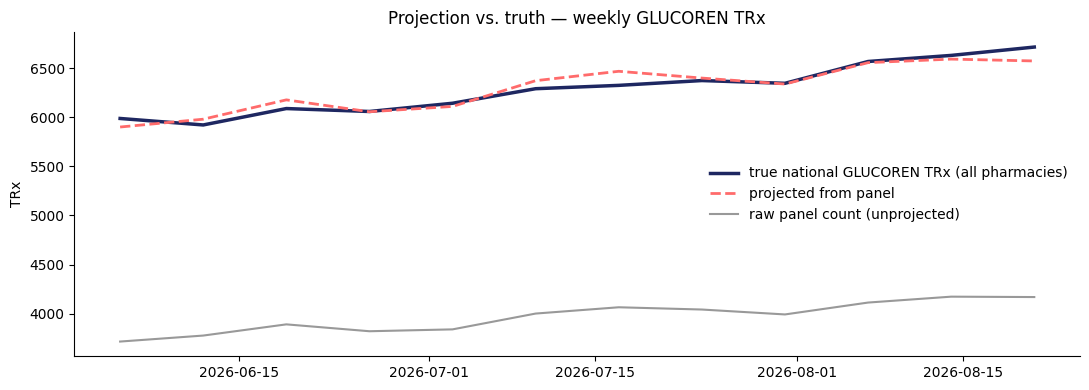

In [5]:
try:
    truth_ph = pd.read_csv(INSTR / "_INSTRUCTOR_panel_universe_pharmacies.csv", dtype={"zip3": str})
    truth_wk = pd.read_csv(INSTR / "_INSTRUCTOR_panel_universe_weekly_trx.csv", parse_dates=["week_ending"])
    truth = truth_wk.groupby("week_ending")[["glucoren_trx", "cardivex_trx"]].sum()
    comp = national.join(truth)
    comp["error_glucoren"] = (comp.proj_glucoren_imputed / comp.glucoren_trx - 1).round(3)
    comp["error_cardivex"] = (comp.proj_cardivex / comp.cardivex_trx - 1).round(3)
    print(comp[["proj_glucoren_imputed", "glucoren_trx", "error_glucoren", "proj_cardivex", "cardivex_trx", "error_cardivex"]])
    print(f"\nmean absolute error — GLUCOREN {comp.error_glucoren.abs().mean():.1%} · CARDIVEX {comp.error_cardivex.abs().mean():.1%}")
    fig, ax = plt.subplots()
    ax.plot(comp.index, comp.glucoren_trx, color=NAVY, lw=2.5, label="true national GLUCOREN TRx (all pharmacies)")
    ax.plot(comp.index, comp.proj_glucoren_imputed, color=CORAL, lw=2, ls="--", label="projected from panel")
    ax.plot(comp.index, comp.panel_glucoren, color=GREY, lw=1.5, label="raw panel count (unprojected)")
    ax.set_title("Projection vs. truth — weekly GLUCOREN TRx"); ax.legend(frameon=False); ax.set_ylabel("TRx")
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print("instructor truth files not present in the student folder")

**What to take from it.** The projected *level* is within a few percent — good enough for a national number, and the week-over-week *trend* is well preserved. The raw panel count would understate the market by roughly half. Where projection fails is **small cells**: one ZIP3 × one specialty stratum × one week is a handful of scripts multiplied by a factor of 2–4. That is exactly the cell an HCP-level target list is built from.

## 4. Longitudinal vs. cross-sectional — the other half of "Rx data"
Everything above is **cross-sectional**: counts of scripts by pharmacy and week, no patient identity. It answers "how much" and "which prescriber". It cannot answer "is this a new patient or a refill", "did they switch from CARDIVEX", or "are they still on therapy in month 6". For those you need **longitudinal, patient-level** data — the same fills, but with a de-identified patient token that persists over time — which is what the DLBCL notebook uses. Patient-level panels have their own capture problem: a patient is only *seen* when they fill at a panel pharmacy (or their payer is in a closed-claims source), so persistence and switching rates are biased by **patient capture**, not just pharmacy coverage.

In [6]:
# NBRx / NRx / TRx on cross-sectional data — what you CAN say
nat_nrx = wk.groupby("week_ending").glucoren_nrx.sum()
print("GLUCOREN NRx share of TRx in the panel (a leading indicator of growth):")
print((nat_nrx / wk.groupby("week_ending").glucoren_trx.sum()).round(3).to_string())
print("\nCaveat: NRx here = 'no fill of this NDC at this pharmacy in the prior 12 months'. Without a patient token it cannot distinguish a genuinely new patient from one who switched pharmacies — that is NBRx, and it needs longitudinal data.")

GLUCOREN NRx share of TRx in the panel (a leading indicator of growth):
week_ending
2026-06-05    0.282
2026-06-12    0.292
2026-06-19    0.292
2026-06-26    0.268
2026-07-03    0.277
2026-07-10    0.277
2026-07-17    0.282
2026-07-24    0.277
2026-07-31    0.286
2026-08-07    0.278
2026-08-14    0.272
2026-08-21    0.281

Caveat: NRx here = 'no fill of this NDC at this pharmacy in the prior 12 months'. Without a patient token it cannot distinguish a genuinely new patient from one who switched pharmacies — that is NBRx, and it needs longitudinal data.


## 5. When to trust a syndicated number — a five-question checklist
1. **Coverage of the strata I care about?** National retail: usually fine. One specialty pharmacy in one metro: no.
2. **How were uncovered cells imputed, and did a big panel member join or leave this period?** Ask for the panel-change log.
3. **Is the metric cross-sectional or patient-level?** TRx trend: cross-sectional is fine. Persistence, switching, new-to-brand: patient-level only.
4. **What does it reconcile to?** Projected TRx × units should track wholesaler shipments (DDD/867) and your own net sales with a lag. If it doesn't, one of the three is wrong.
5. **What is the lag and restatement policy?** Last week's number will be restated next week as late claims arrive. Never compare a fresh week with a mature one.

### Try before Week 3 (not graded)
- Remove the single mail-order pharmacy from the panel and re-run. What happens to the national number?
- Replace the borrowed factor for ZIP3 117 specialty with 1.0 (i.e. ignore it). How big is the bias?
